In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))
from shared.collect_data import DataCollector
from shared.clean_data import DataCleaning
import ta
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
import pandas as pd
import numpy as np

# Data Collection

In [2]:
data_collector = DataCollector(
    symbol = "BTC/USDT", 
    timeframe = "15m", 
    days = 365,
    limit = 1000
)
df = data_collector.collect_data()

# Technical Indicators

### Momentum

In [3]:
##Awesome Oscillator (AO)
df["AO"] = ta.momentum.AwesomeOscillatorIndicator(
    high=df["high"],
    low=df["low"],
    window1=5,
    window2=34
).awesome_oscillator()

##KAMA
df["KAMA"] = ta.momentum.KAMAIndicator(close=df['close']).kama()

## PPO
ppo = ta.momentum.PercentagePriceOscillator(
    close=df['close'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PPO"] = ppo.ppo()

df["PPO_HIST"] = ppo.ppo_hist()

df["PPO_SIGNAL"] = ppo.ppo_signal()

## PVO
pvo = ta.momentum.PercentageVolumeOscillator(
    volume =df['volume'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PVO"] = pvo.pvo()

df["PVO_HIST"] = pvo.pvo_hist()

df["PVO_SIGNAL"] = pvo.pvo_signal()

## ROC
df["ROC"] = ta.momentum.ROCIndicator(
    close=df['close'],
    window=12
).roc()

## RSI
df["RSI"] = ta.momentum.RSIIndicator(close=df['close'], window=14).rsi()

## STOCHASTIC RSI
df["STOCH_RSI"] = ta.momentum.StochRSIIndicator(
    close=df['close'],
    window=14,
    smooth1=3,
    smooth2=3
).stochrsi()

## STOCHASTIC OSCILLATOR
stoch = ta.momentum.StochasticOscillator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    window=14,
    smooth_window=3
)

df["STOCH_OSC"] = stoch.stoch()

df["STOCH_OSC_SIGNAL"] = stoch.stoch_signal()

## TSI
df["TSI"] = ta.momentum.TSIIndicator(
    close=df['close'],
    window_slow=25,
    window_fast=13
).tsi()

### Volume

In [4]:
## ADI
adi = ta.volume.AccDistIndexIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume']
)

df["ADI"] = adi.acc_dist_index()

## CMF
cmf = ta.volume.ChaikinMoneyFlowIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume'],
    window=20
)

df["CMF"] = cmf.chaikin_money_flow()

##EoM EMV
emi = ta.volume.EaseOfMovementIndicator(
    high=df["high"], low=df["low"], volume=df["volume"], window=14
)

df["EoM"] = emi.ease_of_movement()
df["EMV"] = emi.sma_ease_of_movement()

##FI
fi = ta.volume.ForceIndexIndicator(
    close=df["close"], volume=df["volume"], window=13
)

df["FI"] = fi.force_index()

##MFI
mfi = ta.volume.MFIIndicator(
    high=df["high"], low=df["low"], close=df["close"], volume=df["volume"], window=14
)

df["MFI"] = mfi.money_flow_index()

##NVI
nvi = ta.volume.NegativeVolumeIndexIndicator(
    close=df["close"], volume=df["volume"]
)

df["NVI"] = nvi.negative_volume_index()

##OBV
obv = ta.volume.OnBalanceVolumeIndicator(
    close=df["close"], volume=df["volume"]
)

df["OBV"] = obv.on_balance_volume()

##VPT
vpt = ta.volume.VolumePriceTrendIndicator(
    close=df["close"], volume=df["volume"]
)

df["VPT"] = vpt.volume_price_trend()

## VWAP
vwap = ta.volume.VolumeWeightedAveragePrice(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    volume=df["volume"],
    window=14
)

df["VWAP"] = vwap.volume_weighted_average_price()

### Volatility

In [5]:
## ATR
atr = ta.volatility.AverageTrueRange(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ATR"] = atr.average_true_range()

## BBANDS
bbands = ta.volatility.BollingerBands(
    close=df["close"],
    window=20,
    window_dev=2
)

df["BBANDS_HIGH"] = bbands.bollinger_hband()
df["BBANDS_HIGH_INDI"] = bbands.bollinger_hband_indicator()
df["BBANDS_LOWER"] = bbands.bollinger_lband()
df["BBANDS_LOWER_INDI"] = bbands.bollinger_lband_indicator()
df["BBANDS_MIDDLE"] = bbands.bollinger_mavg()
df["BBANDS_CHANNEL"] = bbands.bollinger_pband()
df["BBANDS_WIDTH"] = bbands.bollinger_wband()

## DONCHIAN CHANNEL
donchian = ta.volatility.DonchianChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["DONCHIAN_HIGH"] = donchian.donchian_channel_hband()
df["DONCHIAN_LOW"] = donchian.donchian_channel_lband()
df["DONCHIAN_MIDDLE"] = donchian.donchian_channel_mband()
df["DONCHIAN_PERCENTAGE"] = donchian.donchian_channel_pband()
df["DONCHIAN_WIDTH"] = donchian.donchian_channel_wband()

## KELTNER CHANNEL
keltner = ta.volatility.KeltnerChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20,
    window_atr=10,
)

df["KELTNER_HIGH"] = keltner.keltner_channel_hband()
df["KELTNER_HIGH_INDI"] = keltner.keltner_channel_hband_indicator()
df["KELTNER_LOW"] = keltner.keltner_channel_lband()
df["KELTNER_LOW_INDI"] = keltner.keltner_channel_lband_indicator()
df["KELTNER_MIDDLE"] = keltner.keltner_channel_mband()
df["KELTNER_PERCENTAGE"] = keltner.keltner_channel_pband()
df["KELTNER_WIDTH"] = keltner.keltner_channel_wband()

## Ulcer Index
ui = ta.volatility.UlcerIndex(
    close=df["close"],
    window=14
)

df["ULCER_INDEX"] = ui.ulcer_index()

### Trend

In [6]:
## ADX
adx = ta.trend.ADXIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ADX"] = adx.adx()
df["ADX_POS"] = adx.adx_pos()
df["ADX_NEG"] = adx.adx_neg()

## AROON
aroon = ta.trend.AroonIndicator(
    high=df["high"],
    low=df["low"],
    window=25
)

df["AROON_UP"] = aroon.aroon_up()
df["AROON_DOWN"] = aroon.aroon_down()
df["AROON_INDI"] = aroon.aroon_indicator()

## CCI
cci = ta.trend.CCIIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["CCI"] = cci.cci()

## DPO
dpo = ta.trend.DPOIndicator(
    close=df["close"],
    window=20
)

df["DPO"] = dpo.dpo()

## EMA
ema = ta.trend.EMAIndicator(
    close=df["close"],
    window=14
)

df["EMA"] = ema.ema_indicator()

## KST
kst = ta.trend.KSTIndicator(
    close=df["close"],
    roc1=10,
    roc2=15,
    roc3=20,
    roc4=30,
    window1=10,
    window2=10,
    window3=10,
    window4=15,
    nsig =9
)

df["KST"] = kst.kst()
df["KST_SIGNAL"] = kst.kst_sig()
df["KST_DIFF"] = kst.kst_diff()

## MACD
macd = ta.trend.MACD(
    close=df["close"],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["MACD"] = macd.macd()
df["MACD_SIGNAL"] = macd.macd_signal()
df["MACD_DIFF"] = macd.macd_diff()

## MI
mi = ta.trend.MassIndex(
    high=df["high"],
    low=df["low"],
    window_slow=25,
    window_fast=9
)

df["MASS_INDEX"] = mi.mass_index()

## SMA
sma = ta.trend.SMAIndicator(
    close=df["close"],
    window=14
)

df["SMA"] = sma.sma_indicator()

## VI
vi = ta.trend.VortexIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14
)

df["VI_POS"] = vi.vortex_indicator_pos()
df["VI_NEG"] = vi.vortex_indicator_neg()
df["VI_DIFF"] = vi.vortex_indicator_diff()

## WMA
wma = ta.trend.WMAIndicator(
    close=df["close"],
    window=14
)

df["WMA"] = wma.wma()

# Data Cleaning

In [9]:
dataset = df.copy()
dataset = DataCleaning(dataset).clean_data()

# Feature Engineering

### Timestamp Features

In [10]:
dataset["hour"] = dataset['timestamp'].dt.hour
dataset['dayofweek'] = dataset['timestamp'].dt.dayofweek
dataset['quarter'] = dataset['timestamp'].dt.quarter
dataset['month'] = dataset['timestamp'].dt.month
dataset['year'] = dataset['timestamp'].dt.year
dataset['dayofyear'] = dataset['timestamp'].dt.dayofyear
dataset['dayofmonth'] = dataset['timestamp'].dt.day

### Lag Features (Targets)

In [11]:
def create_targets(df, target_column='close', n_steps=16):
    
    for step in range(1, n_steps + 1):
        df[f'close_step_{step}'] = df[target_column].shift(-step)
    
    return df

In [13]:
dataset = create_targets(dataset, target_column='close', n_steps=16)

In [15]:
dataset = DataCleaning(dataset).clean_data()

# Feature Selection

In [17]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

In [18]:
dataset = dataset.sort_values('timestamp')

In [20]:
TARGET = ['close_step_1', 'close_step_2', 'close_step_3', 'close_step_4', 'close_step_5', 'close_step_6', 'close_step_7', 'close_step_8', 'close_step_9', 'close_step_10', 'close_step_11', 'close_step_12', 'close_step_13', 'close_step_14', 'close_step_15', 'close_step_16']
DROP_COLUMNS = ['timestamp'] + TARGET

In [22]:
def X_y_split(df, target='', drop_columns=[]):
    X = dataset.drop(columns=drop_columns)
    y = dataset[target]
    return X, y

### Feature Importance

In [23]:
xgb_close = XGBRegressor(eval_metric="rmse", early_stopping_rounds=100)

In [24]:
tscv = TimeSeriesSplit(n_splits=100)

##### Train the model

In [25]:
## Train the model
def model_training(X, y, model, tscv):
    fold_metrics = []
    n = len(X)
    oof_pred = np.full(shape=n, fill_value=np.nan, dtype=float)
    feature_names = X.columns.tolist()
    fold_id = 0
    gain_accum = pd.Series(0.0, index=feature_names)

    for train_idx, val_idx in tscv.split(X):
        fold_id += 1
        X_train, X_test = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False,
        )

        # OOF predictions for this fold’s validation window
        y_val_pred = model.predict(X_test)
        oof_pred[val_idx] = y_val_pred

        # Fold metrics
        rmse = root_mean_squared_error(y_test, y_val_pred)
        mae  = mean_absolute_error(y_test, y_val_pred)
        fold_metrics.append({"fold": fold_id, "rmse": rmse, "mae": mae})

        # Gain importances for this fold (reindexed to all features, missing -> 0)
        gain_dict = model.get_booster().get_score(importance_type="gain")
        gain_fold = pd.Series(gain_dict, dtype=float)

        # xgboost keys are the raw feature names; ensure alignment
        gain_fold.index = [k for k in gain_fold.index]  # no-op but explicit
        gain_fold = gain_fold.reindex(feature_names).fillna(0.0)
        gain_accum += gain_fold

    return fold_metrics, oof_pred, gain_accum


# Feature importance for all the targets

In [54]:
features_by_target = {}
for target in TARGET:
    print(f'Feature importance for {target}')
    X, y = X_y_split(dataset, target=target, drop_columns=DROP_COLUMNS)
    fold_metrics, oof_pred, gain_accum = model_training(X, y, xgb_close, tscv)
    importance_df = (
        gain_accum.div(100)             # average gain across folds
        .sort_values(ascending=False)
        .rename("avg_gain")
        .reset_index()
        .rename(columns={"index": "feature"})
    )
    importance_df["gain_pct"] = (importance_df["avg_gain"] / importance_df["avg_gain"].sum()) * 100
    features_by_target[target] = importance_df[importance_df["gain_pct"] > 0.5]["feature"].tolist()


Feature importance for close_step_1
Feature importance for close_step_2
Feature importance for close_step_3
Feature importance for close_step_4
Feature importance for close_step_5
Feature importance for close_step_6
Feature importance for close_step_7
Feature importance for close_step_8
Feature importance for close_step_9
Feature importance for close_step_10
Feature importance for close_step_11
Feature importance for close_step_12
Feature importance for close_step_13
Feature importance for close_step_14
Feature importance for close_step_15
Feature importance for close_step_16


In [59]:
features_by_target["close_step_1"]

['DONCHIAN_HIGH',
 'close',
 'DONCHIAN_LOW',
 'high',
 'low',
 'EMA',
 'DONCHIAN_MIDDLE',
 'KELTNER_HIGH',
 'KAMA',
 'WMA',
 'BBANDS_HIGH',
 'KELTNER_LOW',
 'VWAP',
 'dayofyear',
 'BBANDS_MIDDLE',
 'KELTNER_MIDDLE',
 'open',
 'BBANDS_LOWER']

# Train the models

In [55]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [56]:
best_params={'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 1.5, 'colsample_bytree': 0.6}
xgb_open_close = XGBRegressor(objective='reg:squarederror', **best_params)

In [57]:
cutoff_date = dataset['timestamp'].quantile(0.8)
close_train = dataset[dataset['timestamp'] < cutoff_date]
close_test = dataset[dataset['timestamp'] >= cutoff_date]

Performance metrics for close_step_1:
Mean Squared Error (MSE): 1951608.59
Root Mean Squared Error (RMSE): 1397.00
Mean Absolute Error (MAE): 1036.83
R-squared (R2 Score): 0.81


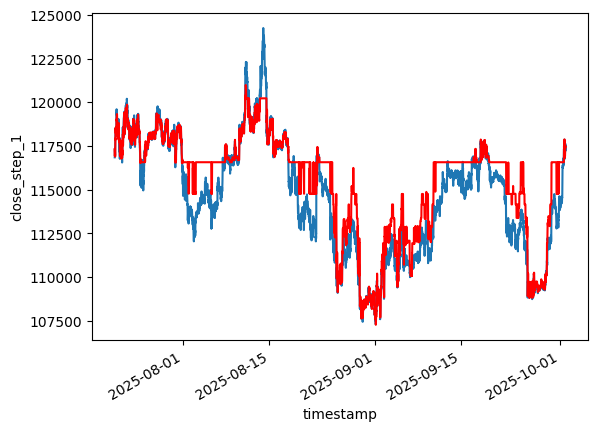

Performance metrics for close_step_2:
Mean Squared Error (MSE): 2768935.10
Root Mean Squared Error (RMSE): 1664.01
Mean Absolute Error (MAE): 1229.17
R-squared (R2 Score): 0.74


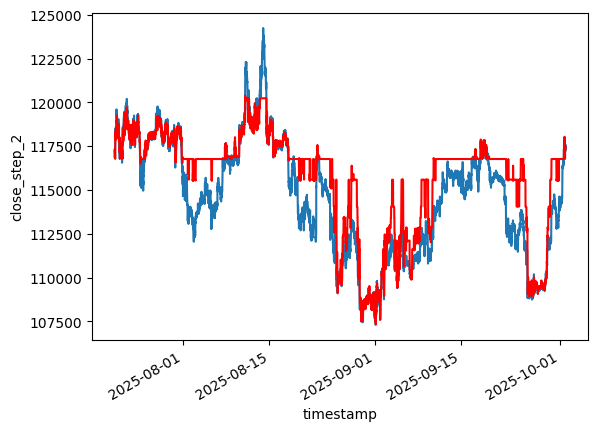

Performance metrics for close_step_3:
Mean Squared Error (MSE): 2615283.38
Root Mean Squared Error (RMSE): 1617.18
Mean Absolute Error (MAE): 1219.91
R-squared (R2 Score): 0.75


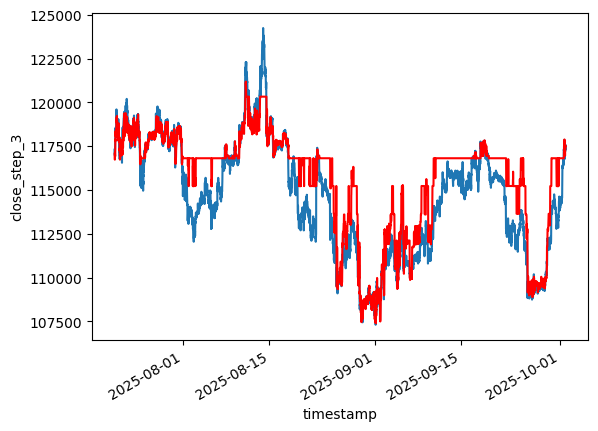

Performance metrics for close_step_4:
Mean Squared Error (MSE): 2878228.97
Root Mean Squared Error (RMSE): 1696.53
Mean Absolute Error (MAE): 1288.73
R-squared (R2 Score): 0.72


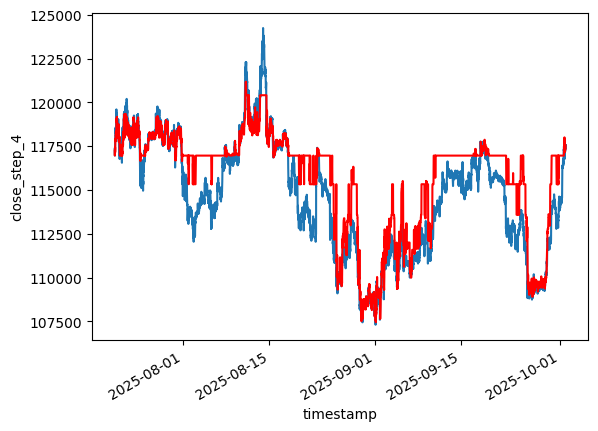

Performance metrics for close_step_5:
Mean Squared Error (MSE): 3545956.17
Root Mean Squared Error (RMSE): 1883.07
Mean Absolute Error (MAE): 1424.07
R-squared (R2 Score): 0.66


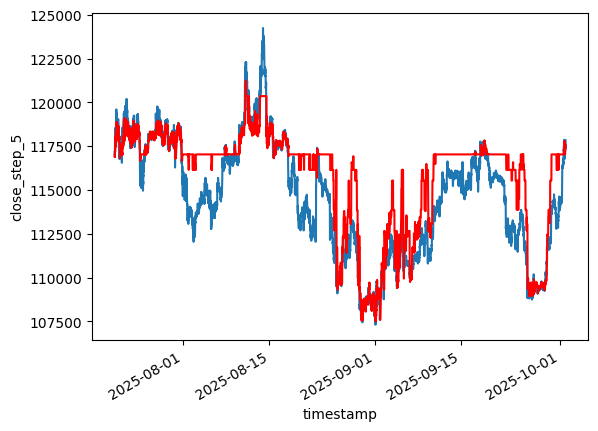

Performance metrics for close_step_6:
Mean Squared Error (MSE): 2898263.24
Root Mean Squared Error (RMSE): 1702.43
Mean Absolute Error (MAE): 1313.99
R-squared (R2 Score): 0.72


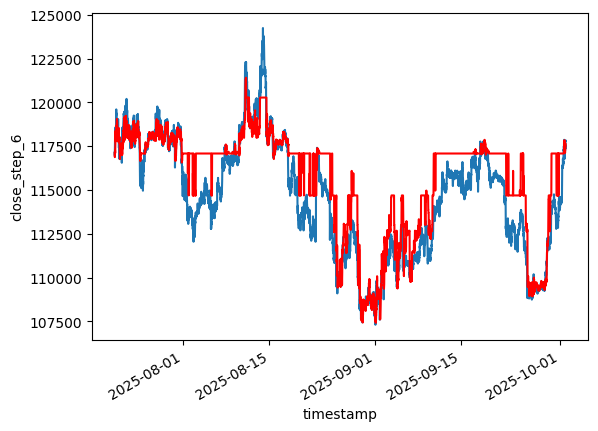

Performance metrics for close_step_7:
Mean Squared Error (MSE): 3880232.68
Root Mean Squared Error (RMSE): 1969.83
Mean Absolute Error (MAE): 1530.37
R-squared (R2 Score): 0.63


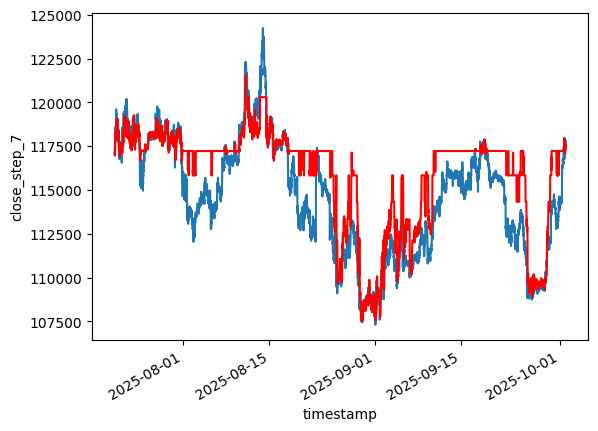

Performance metrics for close_step_8:
Mean Squared Error (MSE): 3339126.32
Root Mean Squared Error (RMSE): 1827.33
Mean Absolute Error (MAE): 1426.64
R-squared (R2 Score): 0.68


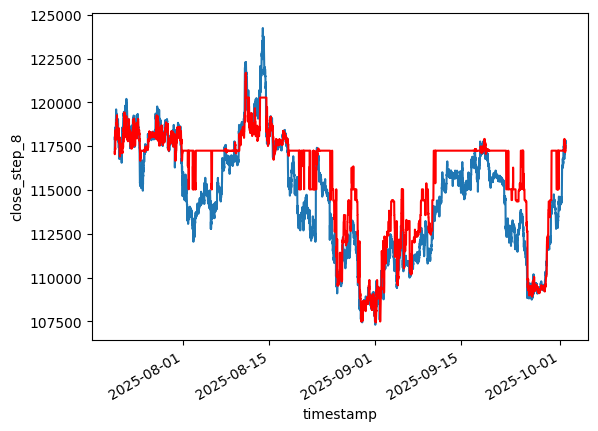

Performance metrics for close_step_9:
Mean Squared Error (MSE): 3758755.18
Root Mean Squared Error (RMSE): 1938.75
Mean Absolute Error (MAE): 1507.66
R-squared (R2 Score): 0.64


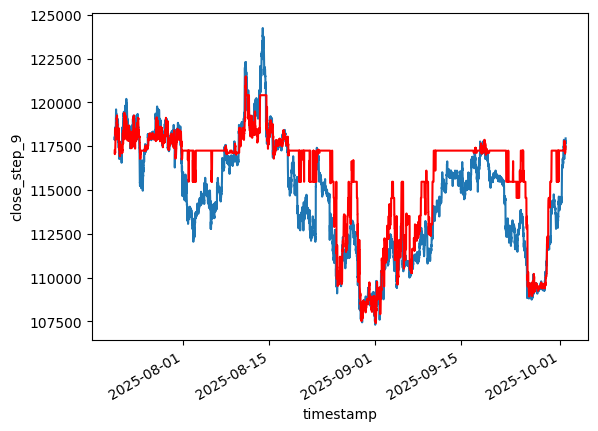

Performance metrics for close_step_10:
Mean Squared Error (MSE): 3848560.44
Root Mean Squared Error (RMSE): 1961.77
Mean Absolute Error (MAE): 1526.50
R-squared (R2 Score): 0.63


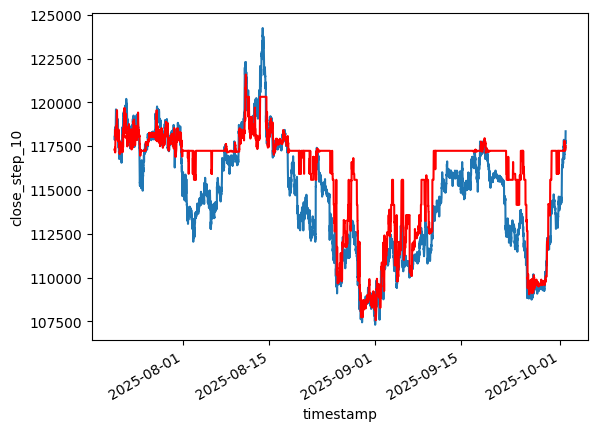

Performance metrics for close_step_11:
Mean Squared Error (MSE): 3644164.59
Root Mean Squared Error (RMSE): 1908.97
Mean Absolute Error (MAE): 1485.08
R-squared (R2 Score): 0.65


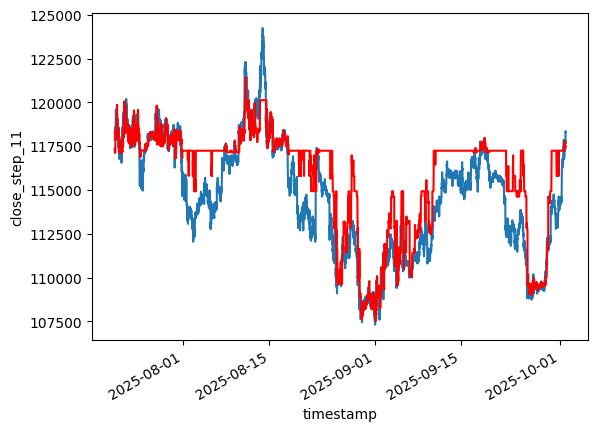

Performance metrics for close_step_12:
Mean Squared Error (MSE): 2616216.35
Root Mean Squared Error (RMSE): 1617.47
Mean Absolute Error (MAE): 1224.90
R-squared (R2 Score): 0.75


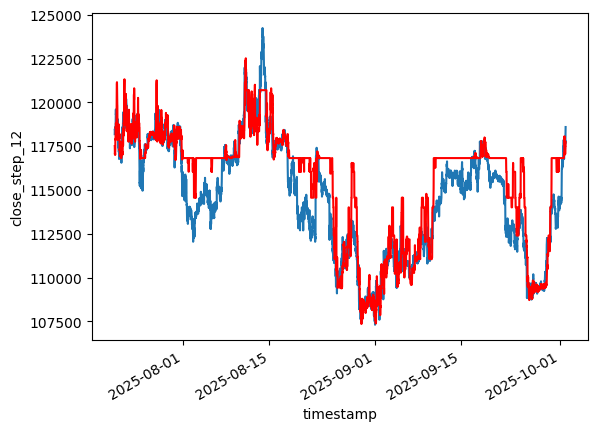

Performance metrics for close_step_13:
Mean Squared Error (MSE): 2842793.01
Root Mean Squared Error (RMSE): 1686.06
Mean Absolute Error (MAE): 1264.08
R-squared (R2 Score): 0.73


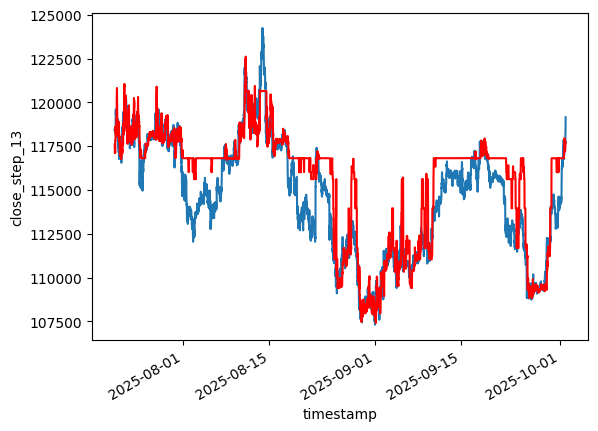

Performance metrics for close_step_14:
Mean Squared Error (MSE): 2997606.41
Root Mean Squared Error (RMSE): 1731.36
Mean Absolute Error (MAE): 1313.20
R-squared (R2 Score): 0.71


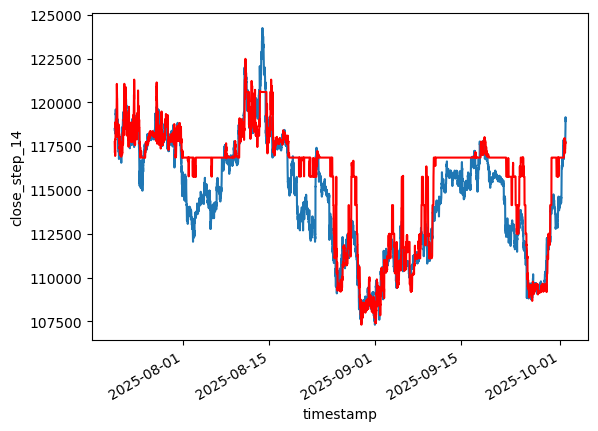

Performance metrics for close_step_15:
Mean Squared Error (MSE): 2997187.76
Root Mean Squared Error (RMSE): 1731.24
Mean Absolute Error (MAE): 1314.10
R-squared (R2 Score): 0.71


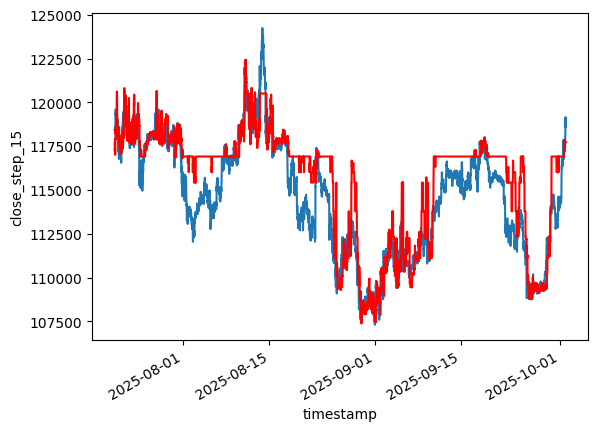

Performance metrics for close_step_16:
Mean Squared Error (MSE): 3040700.55
Root Mean Squared Error (RMSE): 1743.76
Mean Absolute Error (MAE): 1339.21
R-squared (R2 Score): 0.71


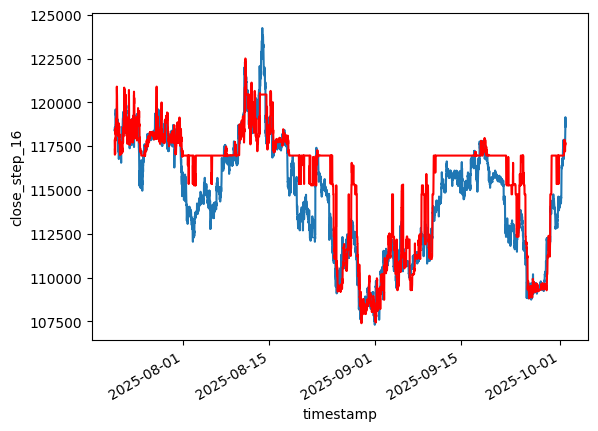

In [58]:
for target in TARGET:
    X_close_train = close_train[features_by_target[target]]
    y_close_train = close_train[target]
    X_close_test = close_test[features_by_target[target]]
    y_close_test = close_test[target]
    xgb_open_close.fit(X_close_train, y_close_train)
    y_pred = xgb_open_close.predict(X_close_test)
    

    print(f"Performance metrics for {target}:")
    mse = mean_squared_error(y_close_test, y_pred)
    rmse = root_mean_squared_error(y_close_test, y_pred)
    mae = mean_absolute_error(y_close_test, y_pred)
    r2 = r2_score(y_close_test, y_pred)

    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"R-squared (R2 Score): {r2:.2f}")

    dataset_compare = close_test.copy()
    dataset_compare[f'{target}_pred'] = y_pred

    sns.lineplot(x="timestamp", y=target, data=dataset_compare)
    sns.lineplot(x="timestamp", y=f'{target}_pred', data=dataset_compare, color="red")
    plt.gcf().autofmt_xdate()
    plt.show()